# **Day 69: Transformers for Language and Vision - BERT-Style Pretraining and the Vision Transformer**
*Module 11 - Advanced Deep Learning*

Day 67 built the Transformer block. Today we use it the two ways that changed AI:
1. **BERT-style** encoders: pretrain on unlabelled text with **masked language modelling** (MLM), then **fine-tune** on a small labelled task.
2. The **Vision Transformer (ViT)**: cut an image into **patches**, treat them as tokens, and apply the same Transformer. ViT-based models (SatMAE, Prithvi, Clay) are the backbone of today's Earth-observation foundation models.

> Transformers pretrained on huge amounts of unlabelled text (BERT-style) or image patches (the Vision Transformer) learn general representations that can then be fine-tuned for specific tasks.
>
> *Example:* A Vision Transformer cuts an image into small patches, treats each patch like a word, and lets attention relate distant parts of the scene.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, math, copy, time
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter
torch.manual_seed(69); rng = np.random.default_rng(69)

class Block(nn.Module):
    """Pre-norm Transformer encoder block (Day 67), using PyTorch's fused attention."""
    def __init__(self, d, heads, d_ff, p=0.1):
        super().__init__(); self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=p, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, d_ff), nn.GELU(), nn.Dropout(p), nn.Linear(d_ff, d)); self.drop = nn.Dropout(p)
    def forward(self, x, pad_mask=None, need_weights=False):
        h = self.ln1(x); a, w = self.attn(h, h, h, key_padding_mask=pad_mask, need_weights=need_weights, average_attn_weights=True)
        x = x + self.drop(a); x = x + self.drop(self.mlp(self.ln2(x)))
        return (x, w) if need_weights else x

## **1. Three Transformer Families**

| Family | Attention | Pretraining objective | Examples | Best for |
|---|---|---|---|---|
| Encoder | bidirectional | masked language modelling | BERT, RoBERTa, SciBERT | classification, extraction, embeddings |
| Decoder | causal | next-token prediction | GPT, LLaMA, Mistral | generation, chat, reasoning |
| Encoder-decoder | both | span corruption / denoising | T5, BART | translation, summarisation |

## **2. A Corpus and a Tokenizer**
We reuse the disaster/agriculture report generator (Day 68): 6,000 **unlabelled** reports for pretraining and only **100 labelled** reports for the downstream classification task.

In [2]:
topics = {
    "flood": (["river", "embankment", "village", "rice field", "road"], ["flooded", "submerged", "inundated", "overflowed"], ["heavy rain", "monsoon downpour", "water level rose", "dam release"]),
    "drought": (["crop", "pond", "well", "paddy", "soil"], ["dried", "withered", "failed", "cracked"], ["no rain", "deficit rainfall", "heat wave", "low groundwater"]),
    "cyclone": (["coast", "fishing boat", "tree", "house roof", "power line"], ["damaged", "uprooted", "blown away", "destroyed"], ["strong wind", "storm surge", "landfall", "gusts"]),
    "landslide": (["hill road", "slope", "village", "highway", "tea garden"], ["blocked", "buried", "collapsed", "slid"], ["debris flow", "steep slope", "continuous rain", "mud and rocks"]),
    "good_crop": (["crop", "rice field", "wheat", "maize", "orchard"], ["flourished", "grew well", "thrived", "ripened"], ["good rain", "timely sowing", "healthy canopy", "fertiliser applied"])}
LABELS = list(topics); districts = ["dhanbad", "bokaro", "ranchi", "midnapore", "puri", "darjeeling", "wayanad", "kutch"]
def report(k, r):
    subj, verb, extra = topics[LABELS[k]]
    s = f"the {r.choice(subj)} {r.choice(verb)} in {r.choice(districts)} after {r.choice(extra)}"
    if r.random() < 0.5: s += f" and {r.choice(extra)}"
    return s
unlab = [report(rng.integers(5), rng) for _ in range(6000)]
lab_y = np.repeat(np.arange(5), 20); lab_txt = [report(k, rng) for k in lab_y]
test_y = np.repeat(np.arange(5), 200); test_txt = [report(k, rng) for k in test_y]

tok = lambda s: re.findall(r"[a-z]+", s.lower())
vocab = ["[PAD]", "[CLS]", "[MASK]", "[UNK]"] + sorted({w for s in unlab for w in tok(s)})
stoi = {w: i for i, w in enumerate(vocab)}; PAD, CLS, MASK, UNK = 0, 1, 2, 3; MAXLEN = 20
def encode(texts):
    ids = torch.zeros(len(texts), MAXLEN, dtype=torch.long)
    for i, t in enumerate(texts):
        seq = [CLS] + [stoi.get(w, UNK) for w in tok(t)][:MAXLEN - 1]; ids[i, :len(seq)] = torch.tensor(seq)
    return ids
U, L, T = encode(unlab), encode(lab_txt), encode(test_txt)
print(f"vocabulary {len(vocab)} tokens | unlabelled {len(U)} | labelled {len(L)} | test {len(T)}")

vocabulary 99 tokens | unlabelled 6000 | labelled 100 | test 1000


## **3. A Mini-BERT and Masked Language Modelling**
MLM: hide 15% of the tokens (replace them by [MASK]) and train the encoder to predict them from **both** sides of context. To fill "the river [MASK] in puri after heavy rain", the model must learn which verbs go with rivers and rain: semantics, from unlabelled text only.

In [3]:
class MiniBERT(nn.Module):
    def __init__(self, V, d=64, heads=4, layers=2, d_ff=128, maxlen=MAXLEN):
        super().__init__()
        self.tok = nn.Embedding(V, d, padding_idx=PAD); self.pos = nn.Parameter(torch.randn(1, maxlen, d) * 0.02)
        self.blocks = nn.ModuleList([Block(d, heads, d_ff) for _ in range(layers)]); self.ln = nn.LayerNorm(d)
        self.mlm_head = nn.Linear(d, V)
    def encode(self, ids):
        pad = ids == PAD; h = self.tok(ids) + self.pos[:, :ids.shape[1]]
        for b in self.blocks: h = b(h, pad)
        return self.ln(h)
    def forward(self, ids):
        return self.mlm_head(self.encode(ids))

def mask_tokens(ids, p=0.15):
    ids = ids.clone(); labels = torch.full_like(ids, -100)                  # -100 = ignored by cross_entropy
    cand = (ids > UNK); m = (torch.rand(ids.shape) < p) & cand
    labels[m] = ids[m]; ids[m] = MASK; return ids, labels

bert = MiniBERT(len(vocab)); opt = torch.optim.AdamW(bert.parameters(), 2e-3, weight_decay=0.01)
t0 = time.perf_counter(); losses = []
for epoch in range(8):
    for s in range(0, len(U), 128):
        x, lbl = mask_tokens(U[s:s + 128])
        loss = F.cross_entropy(bert(x).reshape(-1, len(vocab)), lbl.reshape(-1), ignore_index=-100)
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
print(f"MLM pretraining: loss {losses[0]:.2f} -> {np.mean(losses[-20:]):.2f} in {time.perf_counter() - t0:.0f}s")

def fill_mask(text):
    toks = [CLS] + [MASK if w == "xxx" else stoi.get(w, UNK) for w in tok(text)]; ids = torch.zeros(1, MAXLEN, dtype=torch.long); ids[0, :len(toks)] = torch.tensor(toks)
    bert.eval()
    with torch.no_grad(): logits = bert(ids)[0, toks.index(MASK)]
    return [vocab[i] for i in logits.topk(5).indices]
for q in ["the river xxx in puri after heavy rain", "the crop xxx in kutch after no rain", "the slope xxx in darjeeling after debris flow"]:
    print(f"{q:<48} -> {fill_mask(q)}")

MLM pretraining: loss 4.71 -> 0.78 in 124s
the river xxx in puri after heavy rain           -> ['flooded', 'submerged', 'inundated', 'overflowed', 'road']
the crop xxx in kutch after no rain              -> ['withered', 'cracked', 'dried', 'failed', 'rain']
the slope xxx in darjeeling after debris flow    -> ['slid', 'buried', 'blocked', 'collapsed', 'garden']


## **4. Fine-Tuning on 100 Labelled Reports**
Add a classification head on the [CLS] representation and train the whole network on the small labelled set. Compare with the same architecture trained from scratch.

In [4]:
class BERTClassifier(nn.Module):
    def __init__(self, encoder, n_classes=5):
        super().__init__(); self.encoder = encoder; self.head = nn.Linear(encoder.ln.normalized_shape[0], n_classes)
    def forward(self, ids): return self.head(self.encoder.encode(ids)[:, 0])           # [CLS] token

def finetune(model, epochs=30, lr=5e-4, seed=0):
    torch.manual_seed(seed); opt = torch.optim.AdamW(model.parameters(), lr, weight_decay=0.01)
    dl = DataLoader(TensorDataset(L, torch.tensor(lab_y)), batch_size=16, shuffle=True)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl: opt.zero_grad(); F.cross_entropy(model(xb), yb).backward(); opt.step()
    model.eval()
    with torch.no_grad(): return (model(T).argmax(1).numpy() == test_y).mean()

acc_pre = finetune(BERTClassifier(copy.deepcopy(bert)))
acc_scr = finetune(BERTClassifier(MiniBERT(len(vocab))))
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
acc_tfidf = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=2000)).fit(lab_txt, lab_y).score(test_txt, test_y)
pd.Series({"Transformer from scratch (100 labels)": acc_scr, "MLM-pretrained then fine-tuned (100 labels)": acc_pre, "TF-IDF + logistic regression (100 labels)": acc_tfidf}, name="test accuracy").round(3)

Transformer from scratch (100 labels)          0.998
MLM-pretrained then fine-tuned (100 labels)    1.000
TF-IDF + logistic regression (100 labels)      1.000
Name: test accuracy, dtype: float64

Pretraining on unlabelled text transfers knowledge to the small labelled task: the same principle as ImageNet / SSL4EO pretraining for images (Day 63, 70). (TF-IDF is still a very strong baseline for short, keyword-driven texts like these.)

## **5. The Vision Transformer (ViT)**
Dosovitskiy et al. (2021):
1. Split the image into non-overlapping $P\times P$ patches (e.g. 8x8 pixels x bands).
2. Flatten and linearly project each patch to a $d$-dimensional token (a strided convolution does this).
3. Prepend a [CLS] token, add learned position embeddings, apply Transformer blocks, classify from [CLS].

In [5]:
VEG = [0.04, 0.07, 0.05, 0.30]      # forest, cropland and grassland share ONE mean spectrum: only spatial texture separates them
SPECTRA = {"water": [0.06, 0.05, 0.03, 0.02], "forest": VEG, "cropland": VEG, "grassland": VEG,
           "urban": [0.12, 0.12, 0.13, 0.20], "bare_soil": [0.13, 0.15, 0.18, 0.24]}
CLASSES = list(SPECTRA)

def _norm(t): return (t - t.mean()) / (t.std() + 1e-9)

def make_patch(cls, r, size=32):
    s = np.array(SPECTRA[cls]) * r.uniform(0.75, 1.25) * r.uniform(0.9, 1.1, 4)          # brightness + per-band variation
    yy, xx = np.mgrid[0:size, 0:size]
    if cls == "water": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 6))
    elif cls == "forest": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 0.8))      # fine, rough canopy
    elif cls == "cropland":
        a, per = r.uniform(0, np.pi), r.uniform(5, 10); tex = _norm(np.sin(2 * np.pi * (xx * np.cos(a) + yy * np.sin(a)) / per))   # field stripes
    elif cls == "grassland": tex = _norm(gaussian_filter(r.normal(size=(size, size)), 3))       # smooth patches
    elif cls == "urban":
        b = r.integers(4, 8); tex = _norm((((xx // b) % 2) ^ ((yy // b) % 2)).astype(float))    # block grid
    else: tex = _norm(gaussian_filter(r.normal(size=(size, size)), 4))
    return (s[:, None, None] * (1 + r.uniform(0.15, 0.3) * tex[None]) + r.normal(0, 0.012, (4, size, size))).astype(np.float32)
def make_ds(n, seed):
    r = np.random.default_rng(seed); X = np.stack([make_patch(c, r) for c in SPECTRA for _ in range(n)]); return X, np.repeat(np.arange(6), n)
Xi_tr, yi_tr = make_ds(300, 1); Xi_te, yi_te = make_ds(150, 2)
mu, sd = Xi_tr.mean((0, 2, 3), keepdims=True), Xi_tr.std((0, 2, 3), keepdims=True)
nrm = lambda a: torch.tensor((a - mu) / sd)

class ViT(nn.Module):
    def __init__(self, in_ch=4, img=32, patch=8, d=64, heads=4, layers=4, n_classes=6):
        super().__init__(); n_patches = (img // patch) ** 2
        self.patch_embed = nn.Conv2d(in_ch, d, patch, stride=patch)                # flatten + linear projection of each patch
        self.cls = nn.Parameter(torch.zeros(1, 1, d)); self.pos = nn.Parameter(torch.randn(1, n_patches + 1, d) * 0.02)
        self.blocks = nn.ModuleList([Block(d, heads, 2 * d) for _ in range(layers)]); self.ln = nn.LayerNorm(d); self.head = nn.Linear(d, n_classes)
    def forward(self, x, return_attn=False):
        h = self.patch_embed(x).flatten(2).transpose(1, 2)                           # (B, n_patches, d)
        h = torch.cat([self.cls.expand(len(x), -1, -1), h], 1) + self.pos
        attns = []
        for b in self.blocks:
            h, w = b(h, need_weights=True); attns.append(w)
        out = self.head(self.ln(h[:, 0]))
        return (out, attns) if return_attn else out

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__(); blk = lambda ci, co: nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(), nn.MaxPool2d(2))
        self.net = nn.Sequential(blk(4, 32), blk(32, 64), blk(64, 128), nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, 6))
    def forward(self, x): return self.net(x)

def train_img(model, n_per_class, epochs=30, lr=1e-3):
    idx = np.concatenate([np.flatnonzero(yi_tr == k)[:n_per_class] for k in range(6)])
    torch.manual_seed(0); dl = DataLoader(TensorDataset(nrm(Xi_tr[idx]), torch.tensor(yi_tr[idx])), batch_size=32, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr, weight_decay=0.05); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            k = np.random.default_rng(ep).integers(4); xb = torch.rot90(xb, k, (2, 3))      # rotation augmentation
            opt.zero_grad(); F.cross_entropy(model(xb), yb).backward(); opt.step()
        sched.step()
    model.eval()
    with torch.no_grad(): return (model(nrm(Xi_te)).argmax(1).numpy() == yi_te).mean()

rows = {}
for n in [30, 300]:
    rows[n] = {"CNN": train_img(SmallCNN(), n), "ViT (patch 8)": train_img(ViT(), n)}
print(pd.DataFrame(rows).T.rename_axis("labelled patches per class").round(3))
vit = ViT(); train_img(vit, 300)
print(f"ViT parameters: {sum(p.numel() for p in vit.parameters()):,} | CNN parameters: {sum(p.numel() for p in SmallCNN().parameters()):,}")

                              CNN  ViT (patch 8)
labelled patches per class                      
30                          0.986          0.947
300                         1.000          0.998


ViT parameters: 152,006 | CNN parameters: 94,758


**Inductive bias** (Day 1): CNNs assume locality and translation equivariance; ViTs must **learn** spatial relationships from data. With little data, CNNs usually win; with large data or large-scale **pretraining** (masked autoencoders, Day 70), ViTs match or surpass them and scale better.

### Attention over image patches

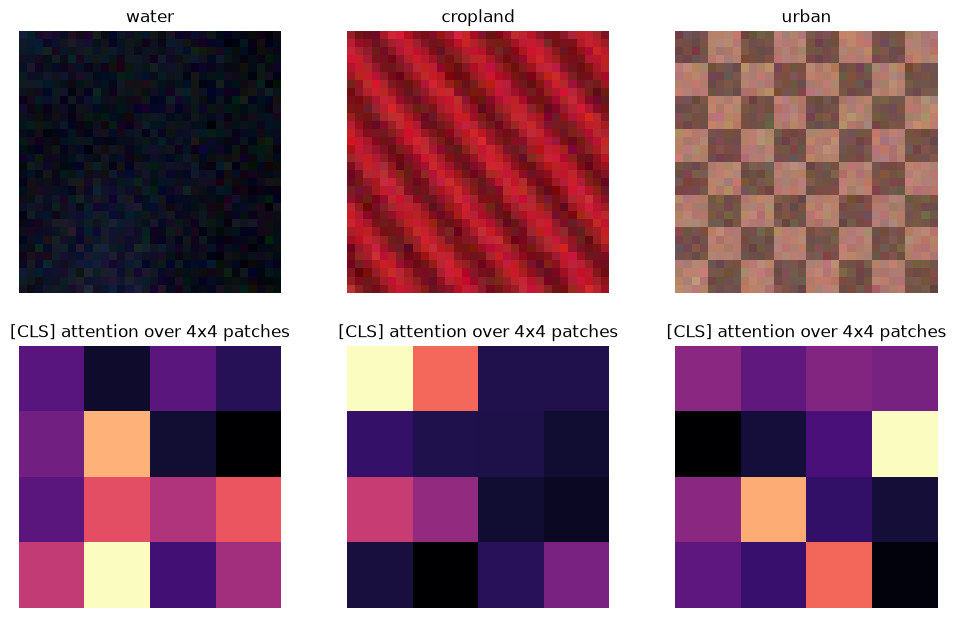

In [6]:
with torch.no_grad(): _, att = vit(nrm(Xi_te[[0, 300, 600]]), return_attn=True)
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
for j, (i, name) in enumerate(zip([0, 300, 600], ["water", "cropland", "urban"])):
    axes[0, j].imshow(np.clip(Xi_te[i][[3, 2, 1]].transpose(1, 2, 0) / 0.4, 0, 1)); axes[0, j].set_title(name)
    axes[1, j].imshow(att[-1][j, 0, 1:].reshape(4, 4).numpy(), cmap="magma"); axes[1, j].set_title("[CLS] attention over 4x4 patches")
for ax in axes.ravel(): ax.axis("off")
plt.show()

# **Part 2: Going Deeper - Pretrained Models From Hugging Face**

In practice we start from **pretrained** weights. With internet access and `pip install transformers`:

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5)
batch = tok(["the river flooded in puri after heavy rain"], padding=True, truncation=True, return_tensors="pt")
logits = model(**batch).logits                       # fine-tune with the usual PyTorch loop or transformers.Trainer

# Vision Transformer / Earth-observation foundation models
from transformers import AutoModelForImageClassification
vit = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224", num_labels=10, ignore_mismatched_sizes=True)
# Prithvi (NASA/IBM): "ibm-nasa-geospatial/Prithvi-EO-2.0-300M" (multispectral HLS, temporal ViT, MAE-pretrained)
```
Domain-specific encoders (SciBERT for scientific text, ClimateBERT, RemoteCLIP for image-text) usually beat general ones in their domain.

## **Practice Problems**
1. Fine-tune the pretrained mini-BERT with only 5 labelled reports per class. How large is the gap to training from scratch now?
2. Change the ViT patch size to 4 (64 tokens) and 16 (4 tokens). How do accuracy and speed change?
3. Freeze the pretrained encoder and train only the classification head (a "linear probe"). Compare with full fine-tuning.
4. *(Advanced)* Use the mean of the mini-BERT token representations (instead of [CLS]) as a sentence embedding and do semantic search over the test reports.

In [7]:
# Solution 1
idx5 = np.concatenate([np.flatnonzero(lab_y == k)[:5] for k in range(5)]); L_full, y_full = L, lab_y
L, lab_y = L_full[idx5], y_full[idx5]
print(f"5 labels/class: pretrained {finetune(BERTClassifier(copy.deepcopy(bert)), epochs=60):.3f} | scratch {finetune(BERTClassifier(MiniBERT(len(vocab))), epochs=60):.3f}")
L, lab_y = L_full, y_full
# Solution 2
for p in [4, 16]:
    t0 = time.perf_counter(); a = train_img(ViT(patch=p), 300, epochs=15); print(f"patch {p:>2}: accuracy {a:.3f} ({time.perf_counter() - t0:.0f}s)")
# Solution 3
probe = BERTClassifier(copy.deepcopy(bert))
for p in probe.encoder.parameters(): p.requires_grad = False
print("linear probe:", round(finetune(probe, lr=5e-3), 3), "| full fine-tuning:", round(acc_pre, 3))
# Solution 4
bert.eval()
def sent_emb(texts):
    ids = encode(texts)
    with torch.no_grad(): h = bert.encode(ids)
    m = (ids != PAD).float().unsqueeze(-1); return F.normalize((h * m).sum(1) / m.sum(1), dim=1)
E_test = sent_emb(test_txt); q = sent_emb(["water rose and the embankment overflowed"])
for i in (E_test @ q[0]).topk(3).indices: print(f"  {test_txt[i]}  [{LABELS[test_y[i]]}]")

5 labels/class: pretrained 0.997 | scratch 0.973


patch  4: accuracy 1.000 (349s)


patch 16: accuracy 0.964 (118s)


linear probe: 1.0 | full fine-tuning: 1.0
  the embankment overflowed in wayanad after water level rose  [flood]
  the road overflowed in wayanad after water level rose  [flood]
  the embankment submerged in wayanad after water level rose  [flood]


## **Key References**
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *NAACL 2019*.
- Radford, A., Narasimhan, K., Salimans, T., & Sutskever, I. (2018). Improving language understanding by generative pre-training. OpenAI technical report.
- Raffel, C. et al. (2020). Exploring the limits of transfer learning with a unified text-to-text transformer. *JMLR*, 21(140), 1-67.
- Dosovitskiy, A. et al. (2021). An image is worth 16x16 words: Transformers for image recognition at scale. *ICLR 2021*.
- Wolf, T. et al. (2020). Transformers: State-of-the-art natural language processing. *EMNLP 2020: System Demonstrations*.
- Jakubik, J. et al. (2023). Foundation models for generalist geospatial artificial intelligence. arXiv:2310.18660 (Prithvi).